# LLM-Guided Chip Placement — Kaggle Runner (Phases 2–4)

Mode A (training-free greedy) on MaskPlace. Setup pulls code+data from GitHub.
gym 0.21.0 can't build on Py3.12 -> we install a tiny `gym` shim. No real gym, no torch.

- **Phase 2**: greedy baseline (133 hard SRAM macros).
- **Phase 3**: hand-fed region constraint (no LLM).
- **Phase 4**: LLM loop — dry-run (free) then real Claude.

Run top to bottom. Phase 4 'real' cell needs an `ANTHROPIC_API_KEY` secret.

## Cell 1 — Setup: clone repo + gym shim + protobuf

In [1]:
import subprocess, sys, os, shutil, types, glob
import numpy as np

REPO_URL  = "https://github.com/dennis5727/arianePlacement.git"
CLONE_DIR = "/kaggle/working/chipPlacement"
WORK_DIR  = os.path.join(CLONE_DIR, "maskplace")

if not os.path.exists(CLONE_DIR):
    try:
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, CLONE_DIR])
        print("cloned ->", CLONE_DIR)
    except Exception as e:
        print("git clone failed (private repo? no internet?):", e)
else:
    subprocess.call(["git", "-C", CLONE_DIR, "pull", "--ff-only"])
    print("repo pulled (latest)")

if not os.path.exists(WORK_DIR):                    # dataset fallback
    hits = glob.glob("/kaggle/input/**/place_db.py", recursive=True)
    assert hits, "No code via git OR dataset. Turn Internet ON or attach the dataset."
    shutil.copytree(os.path.dirname(hits[0]), WORK_DIR)
    print("used dataset fallback ->", WORK_DIR)

os.chdir(WORK_DIR); sys.path.insert(0, WORK_DIR)
print("cwd:", os.getcwd())

os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", "python")
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "protobuf==3.20.3"])
except subprocess.CalledProcessError as e:
    print("protobuf pin failed; relying on pure-python impl:", e)

try:
    import gym  # noqa
    print("real gym:", gym.__version__)
except Exception:
    gym = types.ModuleType("gym"); spaces = types.ModuleType("gym.spaces")
    class _Env: pass
    class _Discrete:
        def __init__(self, n): self.n = int(n)
        def contains(self, x):
            try: x = int(x)
            except (TypeError, ValueError): return False
            return 0 <= x < self.n
    class _Box:
        def __init__(self, low=0, high=1, shape=None, dtype=None):
            self.low, self.high, self.shape, self.dtype = low, high, shape, dtype
    gym.Env=_Env; spaces.Discrete=_Discrete; spaces.Box=_Box; gym.spaces=spaces
    sys.modules["gym"]=gym; sys.modules["gym.spaces"]=spaces
    print("installed gym shim")

try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "anthropic"])
except subprocess.CalledProcessError as e:
    print("anthropic install skipped:", e)

for f in ["place_db.py","place_env/place_env.py","comp_res.py","greedy_place.py",
          "region_constraint.py","llm_guided_placement.py","ariane/netlist.pb.txt"]:
    assert os.path.exists(f), f"MISSING: {f}"
print("files OK\n=== SETUP COMPLETE ===")

Cloning into '/kaggle/working/chipPlacement'...


cloned -> /kaggle/working/chipPlacement
cwd: /kaggle/working/chipPlacement/maskplace
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-cloud-videointelligence 2.19.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-vision 3.14.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
onnx 1.21.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.26 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
grpc-google-iam-v1 0.14.4 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incompatible.
google-cloud-dataplex 2.18.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 3.20.3 which is incom

real gym: 0.26.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.9/923.9 kB 12.3 MB/s eta 0:00:00
files OK
=== SETUP COMPLETE ===


## Cell 2 — Sanity check the engine

In [2]:
from place_db import PlaceDB
placedb = PlaceDB("ariane")
hard = sum(1 for n in placedb.node_info if placedb.node_info[n].get("is_hard"))
print("Nodes:", len(placedb.node_info), "| Nets:", len(placedb.net_info),
      "| Canvas:", placedb.max_height, "| Hard MACROs:", hard)
assert placedb.max_height == 357

area_sum = 99908.97641387026
pin_cnt = 22802
adjust net size = 12404
node_net_num_max 220
node_area_max = 565.3772979022979
Nodes: 932 | Nets: 12404 | Canvas: 357 | Hard MACROs: 133


## Phase 2 — Greedy baseline (133 hard SRAM macros)

Baseline row #1. Expect ~133 placed, **0 overlaps**, HPWL ~8.2e4.

In [3]:
import importlib, greedy_place; importlib.reload(greedy_place)
from greedy_place import greedy_place as run_place
res2 = run_place(benchmark="ariane", hard_only=True, grid=224,
                 save_fig="greedy_hard133.png", verbose=True)
BASELINE = res2["hpwl"]
print(f"\nBaseline HPWL = {BASELINE:.6e}")

area_sum = 99908.97641387026
pin_cnt = 22802
adjust net size = 12404
node_net_num_max 220
node_area_max = 565.3772979022979
[hard_only] placing 133 hard MACROs only (order=keep)
grid * grid 50176
placedb.node_cnt 932
placedb.net_cnt 12404
self.ratio = 1.59
  [  0] i_ariane/ex_stage_i/lsu_i/i_nbdcache/sram_block_5__data_sram/mem/mem_inst_mem_256x128_256x16_0x6 -> cell (  0,  0)  min_wiremask=0  reward=0.0
  [ 10] i_ariane/ex_stage_i/lsu_i/i_nbdcache/sram_block_5__data_sram/mem/mem_inst_mem_256x128_256x16_0x2 -> cell (  0, 26)  min_wiremask=447  reward=-447.0
  [ 20] i_ariane/ex_stage_i/lsu_i/i_nbdcache/sram_block_2__data_sram/mem/mem_inst_mem_256x128_256x16_0x5 -> cell ( 76, 13)  min_wiremask=191  reward=-191.0
  [ 30] i_ariane/ex_stage_i/lsu_i/i_nbdcache/sram_block_2__data_sram/mem/mem_inst_mem_256x128_256x16_0x1 -> cell ( 38, 65)  min_wiremask=109  reward=-83.0
  [ 40] i_ariane/ex_stage_i/lsu_i/i_nbdcache/sram_block_6__data_sram/mem/mem_inst_mem_256x128_256x16_0x3 -> cell ( 57, 78)  m

## Phase 3 — Region constraint (hand-fed, NO LLM)

We supply the regions ourselves and confirm the greedy placer obeys them.

**Test A (clean proof):** force the first 20 macros into the LEFT third (`mid-left`).
Done-when: `out-of-region == 0` (regions respected) **and** HPWL rises vs unconstrained
(a deliberately bad constraint should hurt wirelength).

In [4]:
import importlib, region_constraint, greedy_place
importlib.reload(region_constraint); importlib.reload(greedy_place)
from place_db import PlaceDB
from comp_res import comp_res
from greedy_place import run_greedy, count_overlaps, select_hard_macros
from region_constraint import REGION_LABELS, check_region_compliance

placedb = PlaceDB("ariane")
placedb.node_id_to_name = select_hard_macros(placedb)   # Mode B: hard macros only

# --- Test A: 20 macros, all forced to mid-left ---
pnm = 20
env0,_,_ = run_greedy(placedb, pnm=pnm, grid=224, regions=None, verbose=False)
h0,_ = comp_res(placedb, env0.node_pos, env0.ratio)

regions = {t: "mid-left" for t in range(pnm)}
env1, n, fb = run_greedy(placedb, pnm=pnm, grid=224, regions=regions, verbose=False)
h1,_ = comp_res(placedb, env1.node_pos, env1.ratio)
nviol,_ = check_region_compliance(env1, regions, 224)
env1.save_fig("phase3_leftthird_pnm20.png")

print(f"pnm=20 unconstrained : HPWL={h0:.4e}")
print(f"pnm=20 all->mid-left : HPWL={h1:.4e}  overlaps={count_overlaps(env1)} "
      f"fallback={fb}  out-of-region={nviol}")
print("DONE-WHEN  (non-fallback macros in region AND HPWL rises):", nviol == fb and h1 > h0)

area_sum = 99908.97641387026
pin_cnt = 22802
adjust net size = 12404
node_net_num_max 220
node_area_max = 565.3772979022979
grid * grid 50176
placedb.node_cnt 932
placedb.net_cnt 12404
self.ratio = 1.59
grid * grid 50176
placedb.node_cnt 932
placedb.net_cnt 12404
self.ratio = 1.59
pnm=20 unconstrained : HPWL=9.0765e+03
pnm=20 all->mid-left : HPWL=9.4223e+03  overlaps=0 fallback=2  out-of-region=2
DONE-WHEN  (regions respected AND HPWL rises): False


**Test B (scales to all 133):** round-robin every macro across the 9 regions
(deliberately ignores connectivity). Confirms the mechanism on the full set —
`out-of-region` should be `<= fallback` (only macros that couldn't fit fall back).

In [5]:
pnm = len(placedb.node_id_to_name)
regions = {t: REGION_LABELS[t % 9] for t in range(pnm)}
env, n, fb = run_greedy(placedb, pnm=pnm, grid=224, regions=regions, verbose=False)
hpwl,_ = comp_res(placedb, env.node_pos, env.ratio)
nviol,_ = check_region_compliance(env, regions, 224)
env.save_fig("phase3_roundrobin.png")
print(f"round-robin 133: HPWL={hpwl:.4e} placed={n} overlaps={count_overlaps(env)} "
      f"fallback={fb} out-of-region={nviol}")
print("mechanism OK (only fallbacks are out of region):", nviol <= fb)

grid * grid 50176
placedb.node_cnt 932
placedb.net_cnt 12404
self.ratio = 1.59
round-robin 133: HPWL=2.0806e+05 placed=133 overlaps=0 fallback=0 out-of-region=0
mechanism OK (only fallbacks are out of region): True


20 macros forced left:


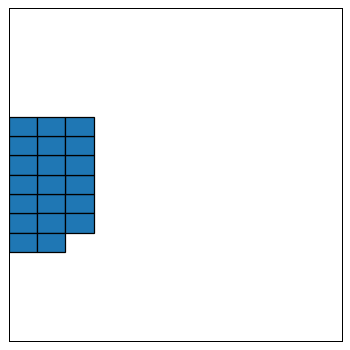

In [6]:
from IPython.display import Image, display
print("20 macros forced left:"); display(Image("phase3_leftthird_pnm20.png"))

## Phase 4 — LLM loop, DRY-RUN (free, no API)

`advisor='dummy'` proposes random regions — this exercises the whole loop
(ordering, history, HPWL recording, early-stop) **without spending any tokens**.
You should see iter 0 baseline, several iters logged, and early-stop trigger.

In [7]:
import importlib, llm_guided_placement; importlib.reload(llm_guided_placement)
from llm_guided_placement import run_llm_loop
dry = run_llm_loop(pnm=30, grid=224, advisor="dummy",
                   max_iters=10, patience=3, save_best_fig="llm_dummy_best.png")

area_sum = 99908.97641387026
pin_cnt = 22802
adjust net size = 12404
node_net_num_max 220
node_area_max = 565.3772979022979
placing 30 macros | advisor=dummy | max_iters=10 | patience=3
grid * grid 50176
placedb.node_cnt 932
placedb.net_cnt 12404
self.ratio = 1.59
iter  0 (no regions): HPWL=1.4742e+04 placed=30 overlaps=0
grid * grid 50176
placedb.node_cnt 932
placedb.net_cnt 12404
self.ratio = 1.59
iter  1: HPWL=4.6494e+04 placed=30 overlaps=0 fallback=0 out-of-region=0
grid * grid 50176
placedb.node_cnt 932
placedb.net_cnt 12404
self.ratio = 1.59
iter  2: HPWL=4.2475e+04 placed=30 overlaps=0 fallback=0 out-of-region=0
grid * grid 50176
placedb.node_cnt 932
placedb.net_cnt 12404
self.ratio = 1.59
iter  3: HPWL=4.2445e+04 placed=30 overlaps=0 fallback=0 out-of-region=0
early stop: no improvement for 3 iterations

=== LLM LOOP RESULT ===
best HPWL   : 1.474227e+04 at iter 0
iter 0 base : 1.474227e+04 (unconstrained greedy)
iterations  : 4
LLM calls   : 3 | input_tokens 0 | output_tokens

## Phase 4 — LLM loop, REAL Claude (costs tokens)

Needs an `ANTHROPIC_API_KEY` Kaggle Secret (Add-ons → Secrets). Each iteration =
1 API call; the chip summary is prompt-cached so repeat calls are cheap.
Baseline (iter 0) is unconstrained greedy; success = best HPWL < baseline.

In [ ]:
import os
from kaggle_secrets import UserSecretsClient
os.environ["ANTHROPIC_API_KEY"] = UserSecretsClient().get_secret("ANTHROPIC_API_KEY")

import importlib, llm_guided_placement; importlib.reload(llm_guided_placement)
from llm_guided_placement import run_llm_loop
res4 = run_llm_loop(pnm=30, grid=224, advisor="claude", model="claude-sonnet-4-6",
                    max_iters=20, patience=3, save_best_fig="llm_claude_best.png")
print(f"\nbaseline={res4['baseline_hpwl']:.4e}  best={res4['best_hpwl']:.4e}  "
      f"calls={res4['llm_calls']}  tokens in/out={res4['in_tokens']}/{res4['out_tokens']}")

In [ ]:
from IPython.display import Image, display
display(Image("llm_claude_best.png"))